# Exploratory Data Analysis & Visualization - Project 2
This notebook loads the SD-WAN measurement dataset, visualizes the delay time-series, highlights packet loss events (delay = -1), and checks the correlation between delay increases and packet losses.

In [69]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Define Paths and Load Data

In [70]:
DATASET_DIR = 'dataset'
FIRST_WINDOW_DIR = os.path.join(DATASET_DIR, 'first_capture_window')

# Let's load CPE A -> CPE B paths for both Fiber and Mobile (4G)
fiber_file = os.path.join(FIRST_WINDOW_DIR, 'cpe_b-cpe_a-fiber.csv')
mobile_file = os.path.join(FIRST_WINDOW_DIR, 'cpe_b-cpe_a-mobile.csv')

df_fiber = pd.read_csv(fiber_file, parse_dates=['time'])
df_mobile = pd.read_csv(mobile_file, parse_dates=['time'])

print(f"Fiber Data: {df_fiber.shape[0]} rows")
print(df_fiber.head(10))

print(f"\nMobile Data: {df_mobile.shape[0]} rows")
print(df_mobile.head(10))

Fiber Data: 113441 rows
                     time  delay_ms
0 2025-03-05 12:26:00.749   15.1341
1 2025-03-05 12:26:01.749   14.3523
2 2025-03-05 12:26:02.750   13.2537
3 2025-03-05 12:26:03.750   18.4053
4 2025-03-05 12:26:04.759   25.0196
5 2025-03-05 12:26:05.759   13.7595
6 2025-03-05 12:26:06.752   57.8543
7 2025-03-05 12:26:07.753   16.9064
8 2025-03-05 12:26:08.755   13.2828
9 2025-03-05 12:47:31.445   -1.0000

Mobile Data: 113441 rows
                     time  delay_ms
0 2025-03-05 12:26:00.749   71.9295
1 2025-03-05 12:26:01.749   71.2723
2 2025-03-05 12:26:02.750   71.2087
3 2025-03-05 12:26:03.749   71.5144
4 2025-03-05 12:26:04.759   70.3835
5 2025-03-05 12:26:05.759   61.2077
6 2025-03-05 12:26:06.753   49.3593
7 2025-03-05 12:26:07.753   67.3919
8 2025-03-05 12:26:08.755   66.7227
9 2025-03-05 12:47:30.446   -1.0000


## 2. Basic Dataset Statistics & Packet Loss Analysis
Packet loss events are marked by `delay_ms = -1`. Let's calculate the packet loss rate and basic statistics of valid delays.

In [71]:
def analyze_packet_loss(df, label):
    total_packets = len(df)
    lost_packets = (df['delay_ms'] == -1).sum()
    loss_rate = (lost_packets / total_packets) * 100
    
    # Exclude packet losses to calculate valid delay statistics
    valid_delays = df[df['delay_ms'] != -1]['delay_ms']
    
    print(f"=== {label} ===")
    print(f"Total rows: {total_packets}")
    print(f"Packet losses (-1): {lost_packets} ({loss_rate:.4f}%)")
    print(f"Valid delay stats (ms):")
    print(f"  Mean:   {valid_delays.mean():.4f}")
    print(f"  Min:    {valid_delays.min():.4f}")
    print(f"  Max:    {valid_delays.max():.4f}")
    print(f"  Std:    {valid_delays.std():.4f}")
    print(f"  95th %: {valid_delays.quantile(0.95):.4f}")
    print(f"  99th %: {valid_delays.quantile(0.99):.4f}")
    print("=" * 30 + "\n")

analyze_packet_loss(df_fiber, "Fiber (CPE A -> B)")
analyze_packet_loss(df_mobile, "Mobile 4G (CPE A -> B)")

=== Fiber (CPE A -> B) ===
Total rows: 113441
Packet losses (-1): 33 (0.0291%)
Valid delay stats (ms):
  Mean:   14.8033
  Min:    9.5211
  Max:    625.3413
  Std:    4.4031
  95th %: 19.6225
  99th %: 28.1107

=== Mobile 4G (CPE A -> B) ===
Total rows: 113441
Packet losses (-1): 251 (0.2213%)
Valid delay stats (ms):
  Mean:   78.5779
  Min:    33.2818
  Max:    994.3062
  Std:    39.4635
  95th %: 145.1385
  99th %: 262.0759



C:\Users\Pietro Guidetti\AppData\Local\Temp\ipykernel_30968\1758627603.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data, labels=['Fiber', '4G'], patch_artist=True, showfliers=False)
C:\Users\Pietro Guidetti\AppData\Local\Temp\ipykernel_30968\1758627603.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


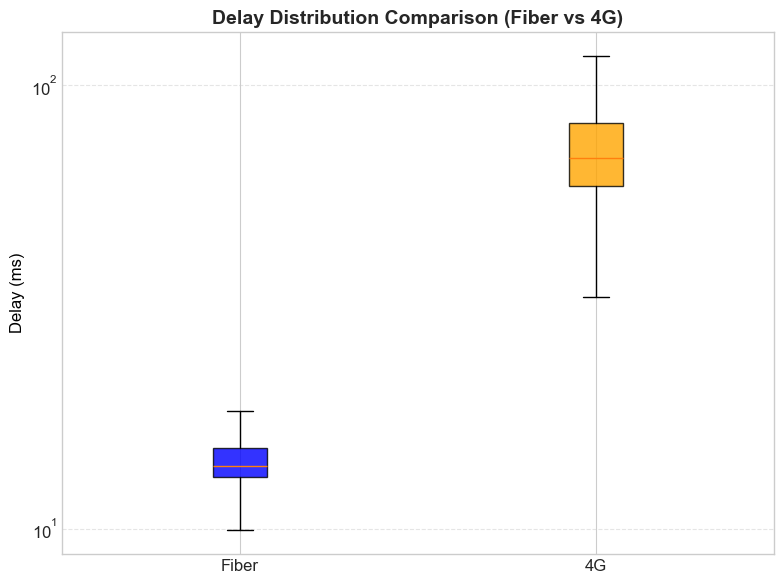

<Figure size 1200x600 with 0 Axes>

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparazione delle serie di ritardo valide (escludendo i packet loss a -1)
fiber_valid = df_fiber['delay_ms'].replace(-1, np.nan).dropna()
mobile_valid = df_mobile['delay_ms'].replace(-1, np.nan).dropna()

# 2. Creazione della figura con un singolo asse (rimossa la logica dei subplots multipli)
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Creazione del boxplot
box_data = [fiber_valid, mobile_valid]
box = ax.boxplot(box_data, labels=['Fiber', '4G'], patch_artist=True, showfliers=False)

# 4. Stile dei box (Colori)
colors = ['blue', 'orange'] # Blu per Fiber, Arancione per 4G
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8) # Aggiunta una leggera trasparenza per un look più pulito


# 6. Formattazione dell'asse (Scala logaritmica e testo)
ax.set_yscale('log')
ax.set_ylabel('Delay (ms)', color='black')
ax.set_title('Delay Distribution Comparison (Fiber vs 4G)', fontsize=14, weight='bold')

# Aggiunta di una griglia orizzontale leggera per facilitare la lettura della scala logaritmica
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

ax.legend()
plt.tight_layout()

plt.show()
plt.savefig('results/raw_data_visualization/boxplot_delay_comparison.png', dpi=300)

## 2.5. Statistical Distributions of Fiber and Mobile Delays
Let's compare the Probability Density Functions (PDF) and Cumulative Distribution Functions (CDF) of the delay measurements to visualize the differences in terms of baseline latency, variability (jitter), and tail behaviors. This is important to assess how similar (or non-IID) the two network types are for model training and Federated Learning aggregation.

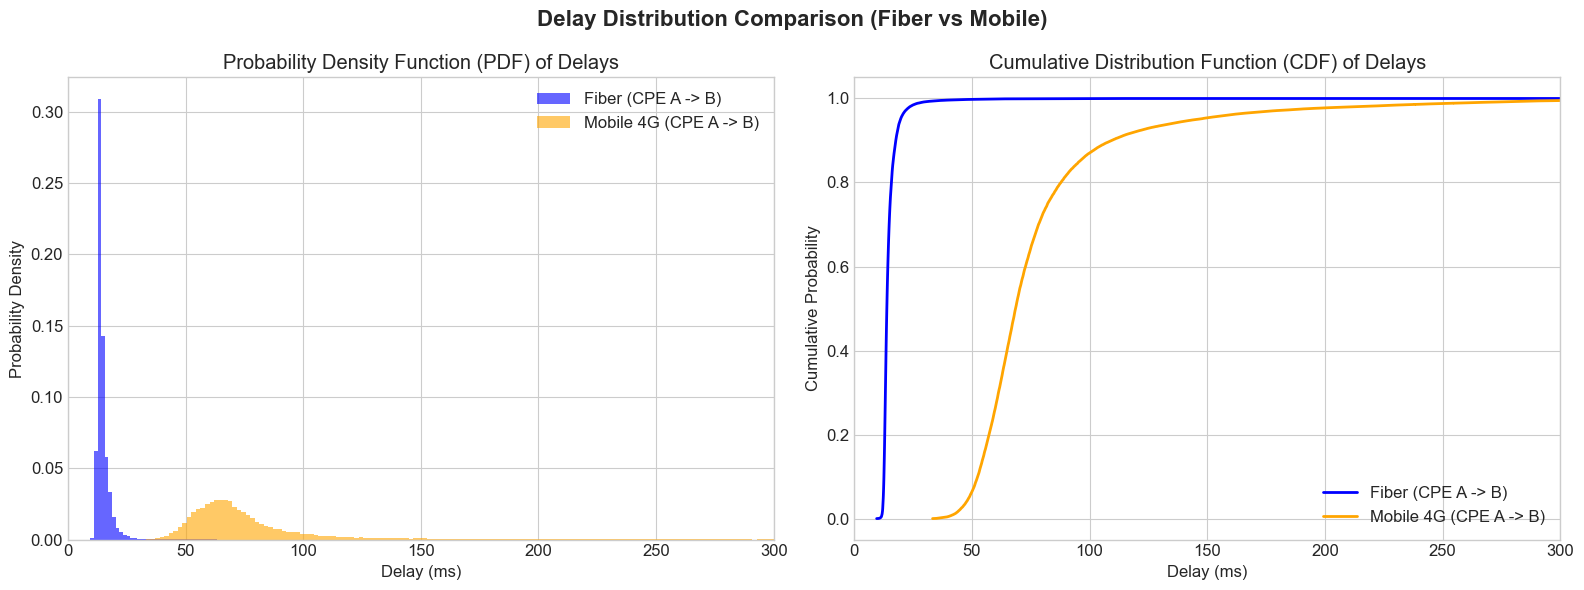

In [73]:

# Exclude packet losses (-1) for statistical plotting
fiber_delays = df_fiber[df_fiber['delay_ms'] != -1]['delay_ms']
mobile_delays = df_mobile[df_mobile['delay_ms'] != -1]['delay_ms']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Probability Density Function (PDF)
# Questo rimane invariato, va benissimo così
axes[0].hist(fiber_delays, bins=400, density=True, alpha=0.6, label='Fiber (CPE A -> B)', color='blue')
axes[0].hist(mobile_delays, bins=500, density=True, alpha=0.6, label='Mobile 4G (CPE A -> B)', color='orange')
axes[0].set_title('Probability Density Function (PDF) of Delays')
axes[0].set_xlabel('Delay (ms)')
axes[0].set_ylabel('Probability Density')
axes[0].set_xlim(0, 300) 
axes[0].legend()

# Plot 2: Cumulative Distribution Function (CDF) - Approccio ECDF
# 1. Ordiniamo i dati
x_fiber = np.sort(fiber_delays)
x_mobile = np.sort(mobile_delays)

# 2. Creiamo l'asse Y (da 0 a 1 in base alla lunghezza dei dati)
y_fiber = np.arange(1, len(x_fiber) + 1) / len(x_fiber)
y_mobile = np.arange(1, len(x_mobile) + 1) / len(x_mobile)

# 3. Plottiamo le curve standard
axes[1].plot(x_fiber, y_fiber, label='Fiber (CPE A -> B)', color='blue', linewidth=2)
axes[1].plot(x_mobile, y_mobile, label='Mobile 4G (CPE A -> B)', color='orange', linewidth=2)

axes[1].set_title('Cumulative Distribution Function (CDF) of Delays')
axes[1].set_xlabel('Delay (ms)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_xlim(0, 300) 
axes[1].legend(loc='lower right')

plt.suptitle('Delay Distribution Comparison (Fiber vs Mobile)', fontsize=16, weight='bold')
plt.tight_layout()

# ATTENZIONE: savefig deve SEMPRE venire prima di show()!
plt.savefig('results/raw_data_visualization/delay_distribution_comparison.png', dpi=300)
plt.show()

## 3. Visualize Raw Delay Time Series
Let's plot the latency values and display where packet losses occur.

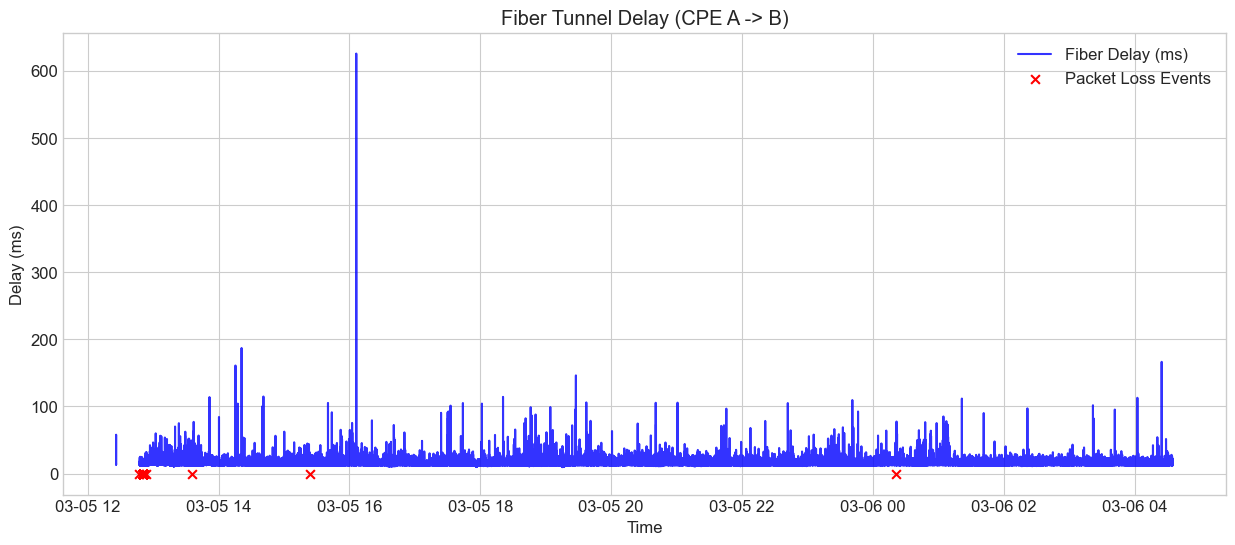

<Figure size 1200x600 with 0 Axes>

In [74]:
# Plotting Fiber delay
plt.figure(figsize=(15, 6))
plt.plot(df_fiber['time'], df_fiber['delay_ms'].replace(-1, np.nan), label='Fiber Delay (ms)', color='blue', alpha=0.8)

# Highlight packet losses as red dots
losses = df_fiber[df_fiber['delay_ms'] == -1]
plt.scatter(losses['time'], [0] * len(losses), color='red', marker='x', label='Packet Loss Events', s=40, zorder=5)

plt.title('Fiber Tunnel Delay (CPE A -> B)')
plt.xlabel('Time')
plt.ylabel('Delay (ms)')
plt.legend()
plt.show()
plt.savefig('results/raw_data_visualization/fiber_delay_time_series.png', dpi=300) 

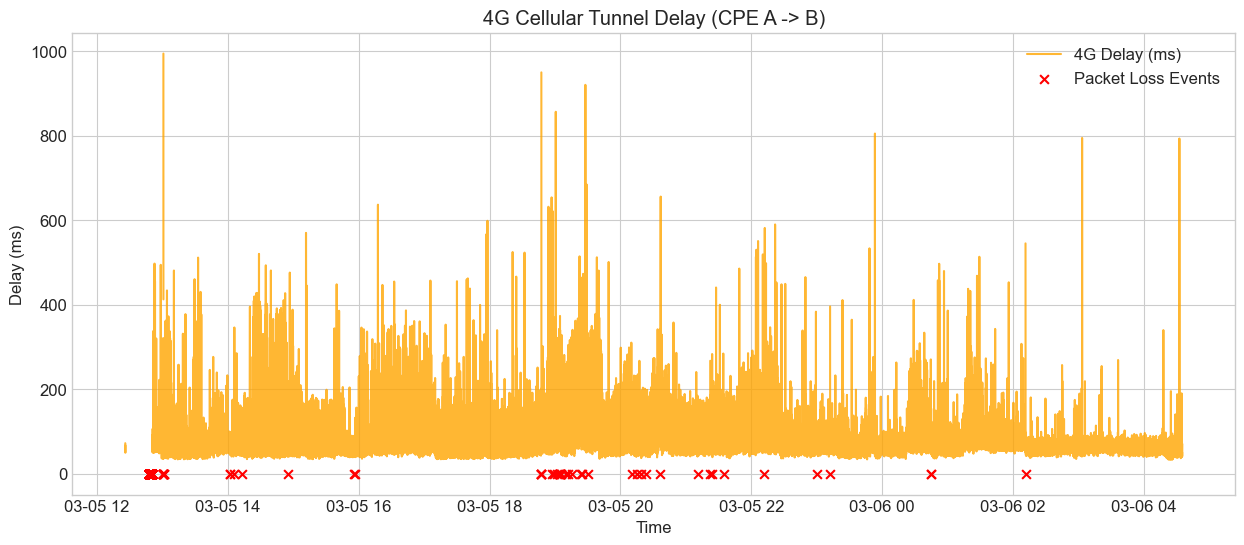

<Figure size 1200x600 with 0 Axes>

In [75]:
# Plotting Mobile delay
plt.figure(figsize=(15, 6))
plt.plot(df_mobile['time'], df_mobile['delay_ms'].replace(-1, np.nan), label='4G Delay (ms)', color='orange', alpha=0.8)

# Highlight packet losses as red dots
losses_m = df_mobile[df_mobile['delay_ms'] == -1]
plt.scatter(losses_m['time'], [0] * len(losses_m), color='red', marker='x', label='Packet Loss Events', s=40, zorder=5)

plt.title('4G Cellular Tunnel Delay (CPE A -> B)')
plt.xlabel('Time')
plt.ylabel('Delay (ms)')
plt.legend()
plt.show()
plt.savefig('results/raw_data_visualization/4g_delay_time_series.png', dpi=300)

## 4. Correlation between Delay and Packet Loss (Dataset Visualized)
This section shows the correlation between packet loss rate and delay increase, similar to the dataset visualization slide in the project description. The left y-axis represents the delay in milliseconds (using a log scale to visualize both fiber and 4G), and the right y-axis represents the packet loss percentage (using a 10-minute rolling average).

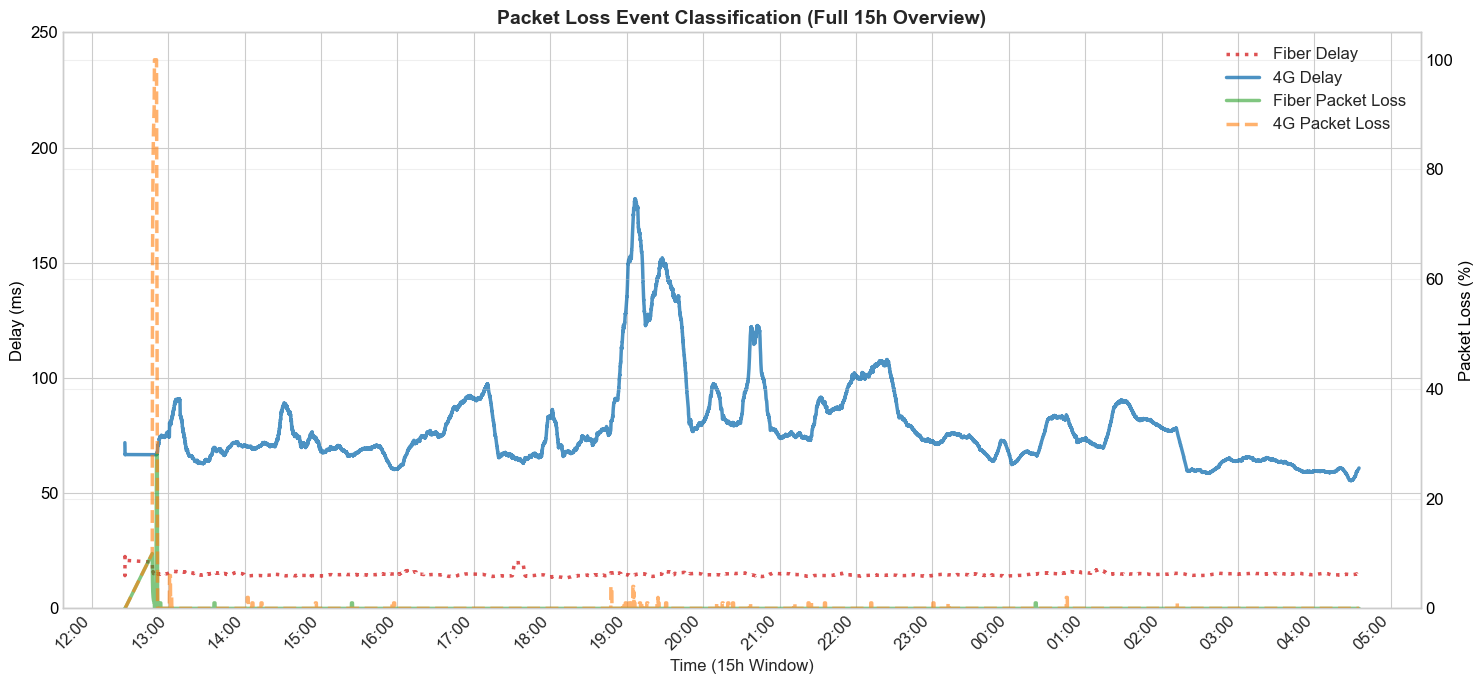

<Figure size 1200x600 with 0 Axes>

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- PREPARAZIONE DATI ---
df_fiber['time'] = pd.to_datetime(df_fiber['time'])
df_mobile['time'] = pd.to_datetime(df_mobile['time'])

# Finestre di smoothing (in secondi, assumendo 1 riga = 1 secondo)
# Su 15 ore (54.000 secondi), finestre da 10 minuti (600) e 1 minuto (60) vanno benissimo
SMOOTHING_WINDOW_LOSS = 100
SMOOTHING_WINDOW_DELAY = 1000 

# Prepare Fiber data
df_fiber_clean = df_fiber.copy()
df_fiber_clean['pkt_loss'] = (df_fiber_clean['delay_ms'] == -1).astype(float)
df_fiber_clean['rolling_loss_pct'] = df_fiber_clean['pkt_loss'].rolling(window=SMOOTHING_WINDOW_LOSS, min_periods=1).mean() * 100
df_fiber_clean['clean_delay'] = df_fiber_clean['delay_ms'].replace(-1, np.nan).ffill()
df_fiber_clean['smooth_delay'] = df_fiber_clean['clean_delay'].rolling(window=SMOOTHING_WINDOW_DELAY, min_periods=1).mean()

# Prepare Mobile data
df_mobile_clean = df_mobile.copy()
df_mobile_clean['pkt_loss'] = (df_mobile_clean['delay_ms'] == -1).astype(float)
df_mobile_clean['rolling_loss_pct'] = df_mobile_clean['pkt_loss'].rolling(window=SMOOTHING_WINDOW_LOSS, min_periods=1).mean() * 100
df_mobile_clean['clean_delay'] = df_mobile_clean['delay_ms'].replace(-1, np.nan).ffill()
df_mobile_clean['smooth_delay'] = df_mobile_clean['clean_delay'].rolling(window=SMOOTHING_WINDOW_DELAY, min_periods=1).mean()


# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# Asse Sinistro (Delay) - Scala Lineare
line1 = ax1.plot(df_fiber_clean['time'], df_fiber_clean['smooth_delay'], label='Fiber Delay', color='#d62728', linestyle=':', alpha=0.8, linewidth=2.5)
line2 = ax1.plot(df_mobile_clean['time'], df_mobile_clean['smooth_delay'], label='4G Delay', color='#1f77b4', alpha=0.8, linewidth=2.5)

ax1.set_xlabel('Time (15h Window)')
ax1.set_ylabel('Delay (ms)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 250) 

# Asse Destro (Packet Loss)
ax2 = ax1.twinx()
line3 = ax2.plot(df_fiber_clean['time'], df_fiber_clean['rolling_loss_pct'], label='Fiber Packet Loss', color='#2ca02c', linestyle='-', alpha=0.6, linewidth=2.5)
line4 = ax2.plot(df_mobile_clean['time'], df_mobile_clean['rolling_loss_pct'], label='4G Packet Loss', color='#ff7f0e', linestyle='--', alpha=0.6, linewidth=2.5)

ax2.set_ylabel('Packet Loss (%)', color='black')
ax2.tick_params(axis='y', labelcolor='black')
# Non fisso l'ylim superiore qui per permettere ad ax2 di scalare automaticamente su tutto il % pkt loss delle 15 ore
ax2.set_ylim(bottom=-0.01) 

# --- FORMATTAZIONE ASSE X (LE 15 ORE) ---
# Formatta l'asse x per mostrare le ore in modo leggibile ("HH:MM")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# Mette una "tick" (tacca) sull'asse X ogni ora per coprire bene le 15 ore
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1)) 
# Ruota le etichette per evitare che si sovrappongano
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Gestione Legenda
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', shadow=True)

plt.title('Packet Loss Event Classification (Full 15h Overview)', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
plt.savefig('results/raw_data_visualization/packet_loss_classification_full_15h.png', dpi=300)

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_network_data(df_fiber, df_mobile, start_time, end_time, smoothing_window_loss, smoothing_window_delay, save_path=None):
    """
    Genera un grafico che confronta il ritardo e la perdita di pacchetti tra Fiber e 4G 
    all'interno di una specifica finestra temporale.
    """
    
    # 1. Assicuriamoci che le colonne 'time' siano datetime (se non lo sono già)
    df_fiber['time'] = pd.to_datetime(df_fiber['time'])
    df_mobile['time'] = pd.to_datetime(df_mobile['time'])
    
    # Converte gli input di tempo in oggetti datetime per il filtraggio
    start_time = pd.to_datetime(start_time)
    end_time = pd.to_datetime(end_time)
    
    # 2. Filtra i dataframe in base alla finestra temporale richiesta
    mask_fiber = (df_fiber['time'] >= start_time) & (df_fiber['time'] <= end_time)
    df_fiber_filtered = df_fiber.loc[mask_fiber].copy()
    
    mask_mobile = (df_mobile['time'] >= start_time) & (df_mobile['time'] <= end_time)
    df_mobile_filtered = df_mobile.loc[mask_mobile].copy()

    # Se i dataframe filtrati sono vuoti, avvisa e ferma la funzione
    if df_fiber_filtered.empty or df_mobile_filtered.empty:
        print("Attenzione: Nessun dato trovato per l'intervallo di tempo specificato.")
        return

    # 3. Prepare Fiber data
    df_fiber_filtered['pkt_loss'] = (df_fiber_filtered['delay_ms'] == -1).astype(float)
    df_fiber_filtered['rolling_loss_pct'] = df_fiber_filtered['pkt_loss'].rolling(window=smoothing_window_loss, min_periods=1).mean() * 100
    df_fiber_filtered['clean_delay'] = df_fiber_filtered['delay_ms'].replace(-1, np.nan).ffill()
    df_fiber_filtered['smooth_delay'] = df_fiber_filtered['clean_delay'].rolling(window=smoothing_window_delay, min_periods=1).mean()

    # 4. Prepare Mobile data
    df_mobile_filtered['pkt_loss'] = (df_mobile_filtered['delay_ms'] == -1).astype(float)
    df_mobile_filtered['rolling_loss_pct'] = df_mobile_filtered['pkt_loss'].rolling(window=smoothing_window_loss, min_periods=1).mean() * 100
    df_mobile_filtered['clean_delay'] = df_mobile_filtered['delay_ms'].replace(-1, np.nan).ffill()
    df_mobile_filtered['smooth_delay'] = df_mobile_filtered['clean_delay'].rolling(window=smoothing_window_delay, min_periods=1).mean()

    # --- PLOTTING ---
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Asse Sinistro (Delay)
    line1 = ax1.plot(df_fiber_filtered['time'], df_fiber_filtered['smooth_delay'], label='Fiber Delay', color='#d62728', linestyle=':', alpha=0.8, linewidth=2.5)
    line2 = ax1.plot(df_mobile_filtered['time'], df_mobile_filtered['smooth_delay'], label='4G Delay', color='#1f77b4', alpha=0.8, linewidth=2.5)

    ax1.set_xlabel('Time')
    ax1.set_ylabel('Delay (ms)', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_ylim(0, 250) 

    # Asse Destro (Packet Loss)
    ax2 = ax1.twinx()
    line3 = ax2.plot(df_fiber_filtered['time'], df_fiber_filtered['rolling_loss_pct'], label='Fiber Packet Loss', color='#2ca02c', linestyle='-', alpha=0.6, linewidth=2.5)
    line4 = ax2.plot(df_mobile_filtered['time'], df_mobile_filtered['rolling_loss_pct'], label='4G Packet Loss', color='#ff7f0e', linestyle='--', alpha=0.6, linewidth=2.5)

    ax2.set_ylabel('Packet Loss (%)', color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.set_ylim(bottom=-0.01) 

    # --- FORMATTAZIONE ASSE X DINAMICA ---
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    # AutoDateLocator sceglie automaticamente la spaziatura migliore per i tick in base allo zoom
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator()) 
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Gestione Legenda
    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', shadow=True)

    plt.title(f'Packet Loss Event Classification ({start_time} to {end_time})', fontsize=14, weight='bold')
    plt.grid(True, alpha=0.3)
    fig.tight_layout()

    # Gestione Salvataggio
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Grafico salvato in: {save_path}")
        
    plt.show()


Grafico salvato in: results/raw_data_visualization/packet_loss_custom_window.png


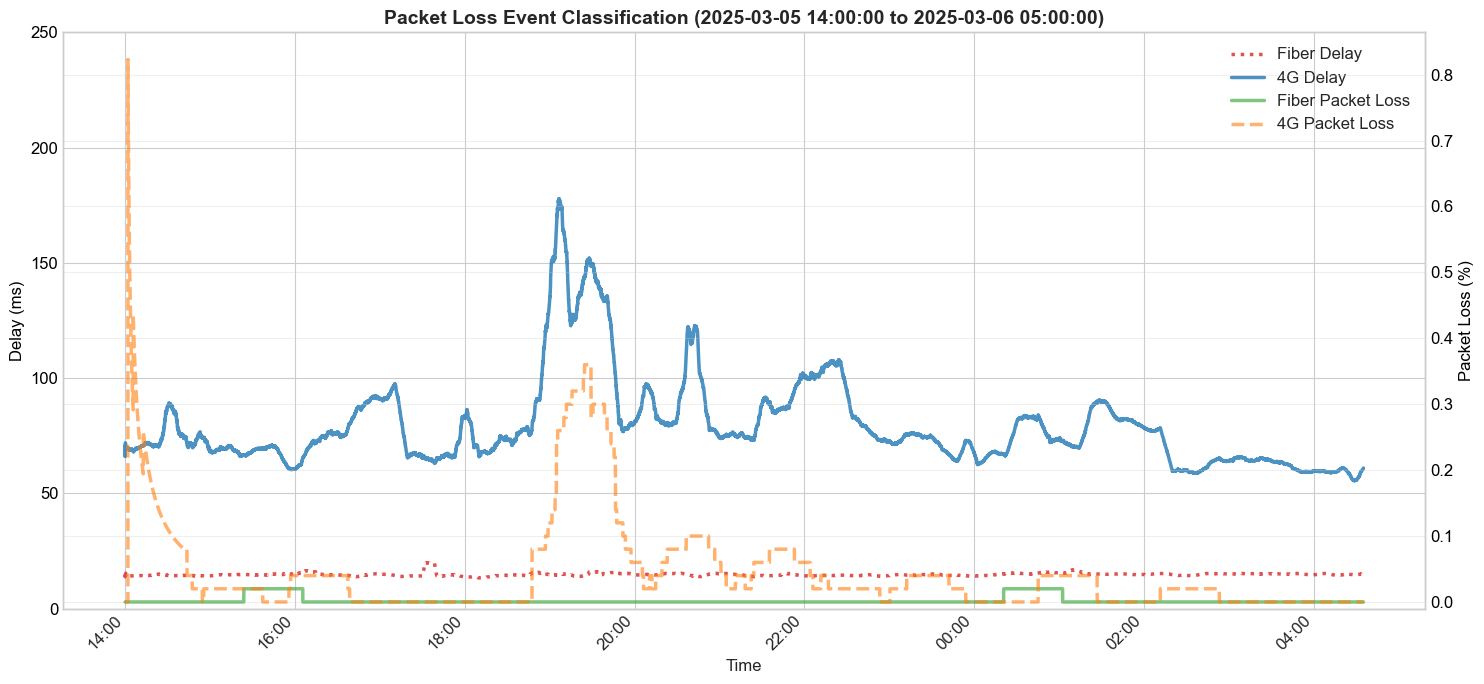

In [78]:
# --- ESEMPIO DI UTILIZZO DELLA FUNZIONE ---
# Sostituisci le stringhe di tempo con quelle reali presenti nel tuo dataset

plot_network_data(
    df_fiber=df_fiber, 
    df_mobile=df_mobile, 
    start_time='2025-03-05 14:00:00',  # Sostituisci con il tuo orario di inizio
    end_time='2025-03-06 05:00:00',    # Sostituisci con il tuo orario di fine
    smoothing_window_loss=5000, 
    smoothing_window_delay=1000,
    save_path='results/raw_data_visualization/packet_loss_custom_window.png'
)

Grafico salvato in: results/raw_data_visualization/packet_loss_custom_window.png


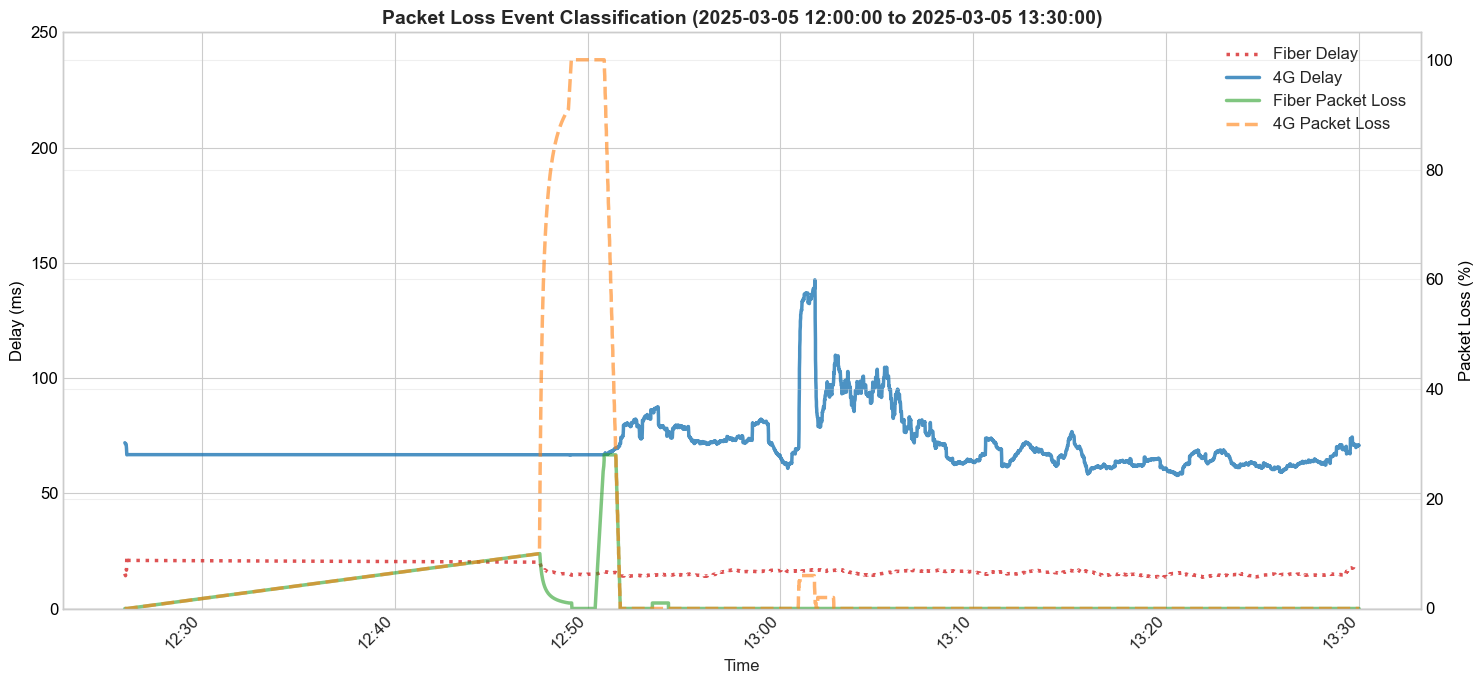

In [79]:
plot_network_data(
    df_fiber=df_fiber, 
    df_mobile=df_mobile, 
    start_time='2025-03-05 12:00:00',  # Sostituisci con il tuo orario di inizio
    end_time='2025-03-05 13:30:00',    # Sostituisci con il tuo orario di fine
    smoothing_window_loss=100, 
    smoothing_window_delay=100,
    save_path='results/raw_data_visualization/packet_loss_custom_window.png'
)

Grafico salvato in: results/raw_data_visualization/packet_loss_custom_window.png


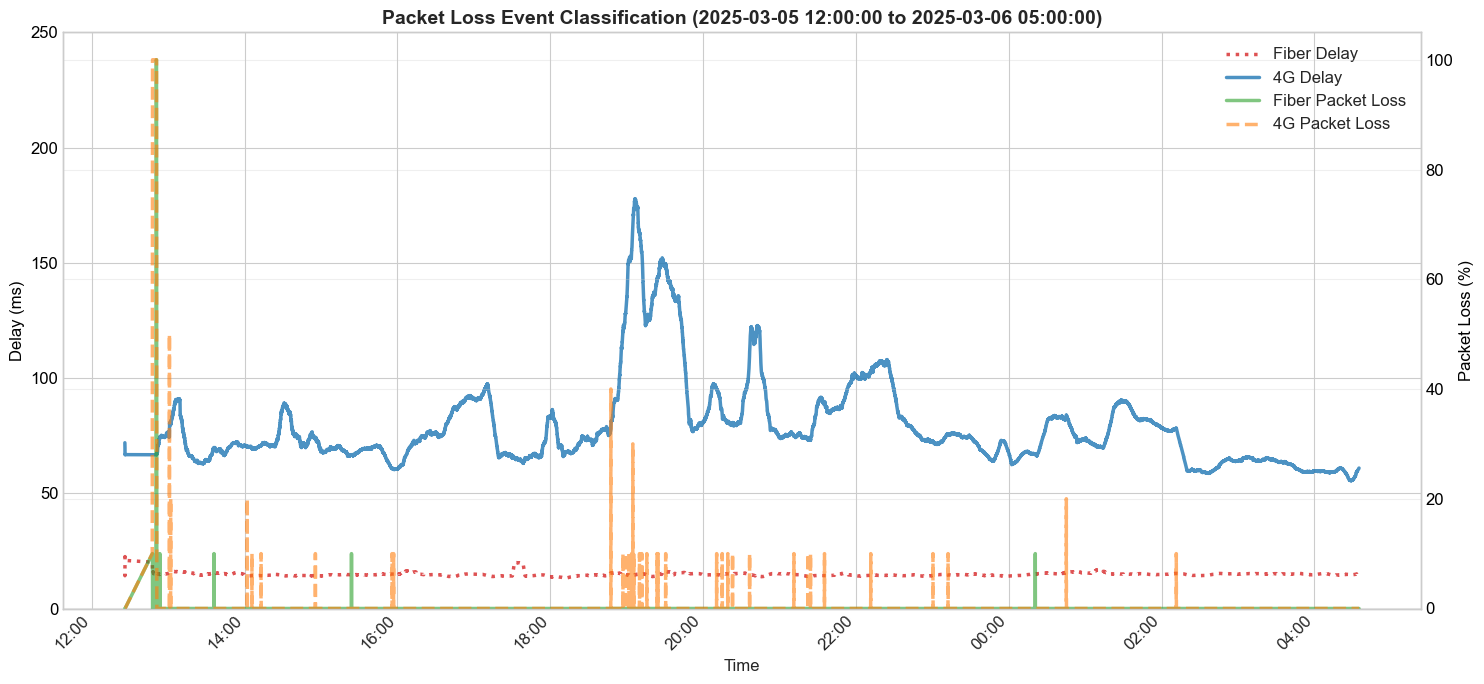

In [80]:
plot_network_data(
    df_fiber=df_fiber, 
    df_mobile=df_mobile, 
    start_time='2025-03-05 12:00:00',  # Sostituisci con il tuo orario di inizio
    end_time='2025-03-06 05:00:00',    # Sostituisci con il tuo orario di fine
    smoothing_window_loss=10, 
    smoothing_window_delay=1000,
    save_path='results/raw_data_visualization/packet_loss_custom_window.png'
)

## 5. Feature Utility Visualization for Modeling
In this section we visualize the additional candidate features requested in the project plan:
- Trend / Slope (linear regression coefficient on recent delay window)
- Rate of delay changes and recent delta
- Historical packet loss counts

To evaluate whether they may be useful for prediction, we compare each feature against a forward-looking label (`future_pkt_loss`), which is `1` when at least one packet loss event appears in the next time window.

In [81]:
from pandas.api.indexers import FixedForwardWindowIndexer

# Feature configuration (you can tune these values)
FEATURE_LOOKBACK = 60      # seconds used to compute trend/rate/history features
RECENT_DELTA_H = 5         # seconds for short-term delay delta
FUTURE_WINDOW = 20         # seconds used to define future packet-loss label


def build_feature_frame(df, tech_name, lookback=60, recent_delta_h=5, future_window=20):
    data = df.copy().sort_values('time').reset_index(drop=True)
    data['time'] = pd.to_datetime(data['time'])

    # Packet loss indicator and cleaned delay series
    data['pkt_loss'] = (data['delay_ms'] == -1).astype(int)
    data['clean_delay'] = data['delay_ms'].replace(-1, np.nan).ffill().bfill()

    # Trend/Slope using linear regression coefficient over a rolling window
    x = np.arange(lookback, dtype=float)
    x_sum = x.sum()
    x2_sum = (x ** 2).sum()
    denom = lookback * x2_sum - x_sum ** 2

    def rolling_slope(y):
        y = np.asarray(y, dtype=float)
        return (lookback * np.sum(x * y) - x_sum * np.sum(y)) / denom

    data['trend_slope'] = data['clean_delay'].rolling(
        window=lookback,
        min_periods=lookback
    ).apply(rolling_slope, raw=True)

    # Rate of delay changes (average absolute variation in the last lookback seconds)
    data['delay_change_rate'] = data['clean_delay'].diff().abs().rolling(
        window=lookback,
        min_periods=1
    ).mean()

    # Recent delay delta (difference against a short recent horizon)
    data['recent_delta'] = data['clean_delay'].diff(periods=recent_delta_h)

    # Historical packet loss counts in the last lookback seconds
    data['hist_loss_count'] = data['pkt_loss'].rolling(window=lookback, min_periods=1).sum()

    # Forward-looking target: any packet loss in the next FUTURE_WINDOW seconds
    indexer = FixedForwardWindowIndexer(window_size=future_window)
    future_series = data['pkt_loss'].shift(-1).rolling(indexer, min_periods=1).max()
    data['future_pkt_loss'] = future_series.fillna(0).astype(int)

    data['technology'] = tech_name

    return data[[
        'time',
        'technology',
        'trend_slope',
        'delay_change_rate',
        'recent_delta',
        'hist_loss_count',
        'future_pkt_loss'
    ]]


fiber_features = build_feature_frame(
    df_fiber,
    tech_name='Fiber',
    lookback=FEATURE_LOOKBACK,
    recent_delta_h=RECENT_DELTA_H,
    future_window=FUTURE_WINDOW
)

mobile_features = build_feature_frame(
    df_mobile,
    tech_name='4G',
    lookback=FEATURE_LOOKBACK,
    recent_delta_h=RECENT_DELTA_H,
    future_window=FUTURE_WINDOW
)

feature_df = pd.concat([fiber_features, mobile_features], ignore_index=True)

print('Feature frame created:')
print(feature_df.head())

print('\nCorrelation with future packet-loss label (rough linear indicator):')
for tech, frame in [('Fiber', fiber_features), ('4G', mobile_features)]:
    subset = frame[['trend_slope', 'delay_change_rate', 'recent_delta', 'hist_loss_count', 'future_pkt_loss']].dropna()
    corr = subset.corr(numeric_only=True)['future_pkt_loss'].drop('future_pkt_loss')
    print(f'\n{tech}:')
    print(corr)


Feature frame created:
                     time technology  trend_slope  delay_change_rate  \
0 2025-03-05 12:26:00.749      Fiber          NaN                NaN   
1 2025-03-05 12:26:01.749      Fiber          NaN           0.781800   
2 2025-03-05 12:26:02.750      Fiber          NaN           0.940200   
3 2025-03-05 12:26:03.750      Fiber          NaN           2.344000   
4 2025-03-05 12:26:04.759      Fiber          NaN           3.411575   

   recent_delta  hist_loss_count  future_pkt_loss  
0           NaN              0.0                1  
1           NaN              0.0                1  
2           NaN              0.0                1  
3           NaN              0.0                1  
4           NaN              0.0                1  

Correlation with future packet-loss label (rough linear indicator):

Fiber:
trend_slope          0.010152
delay_change_rate    0.000066
recent_delta         0.001157
hist_loss_count      0.166951
Name: future_pkt_loss, dtype: float

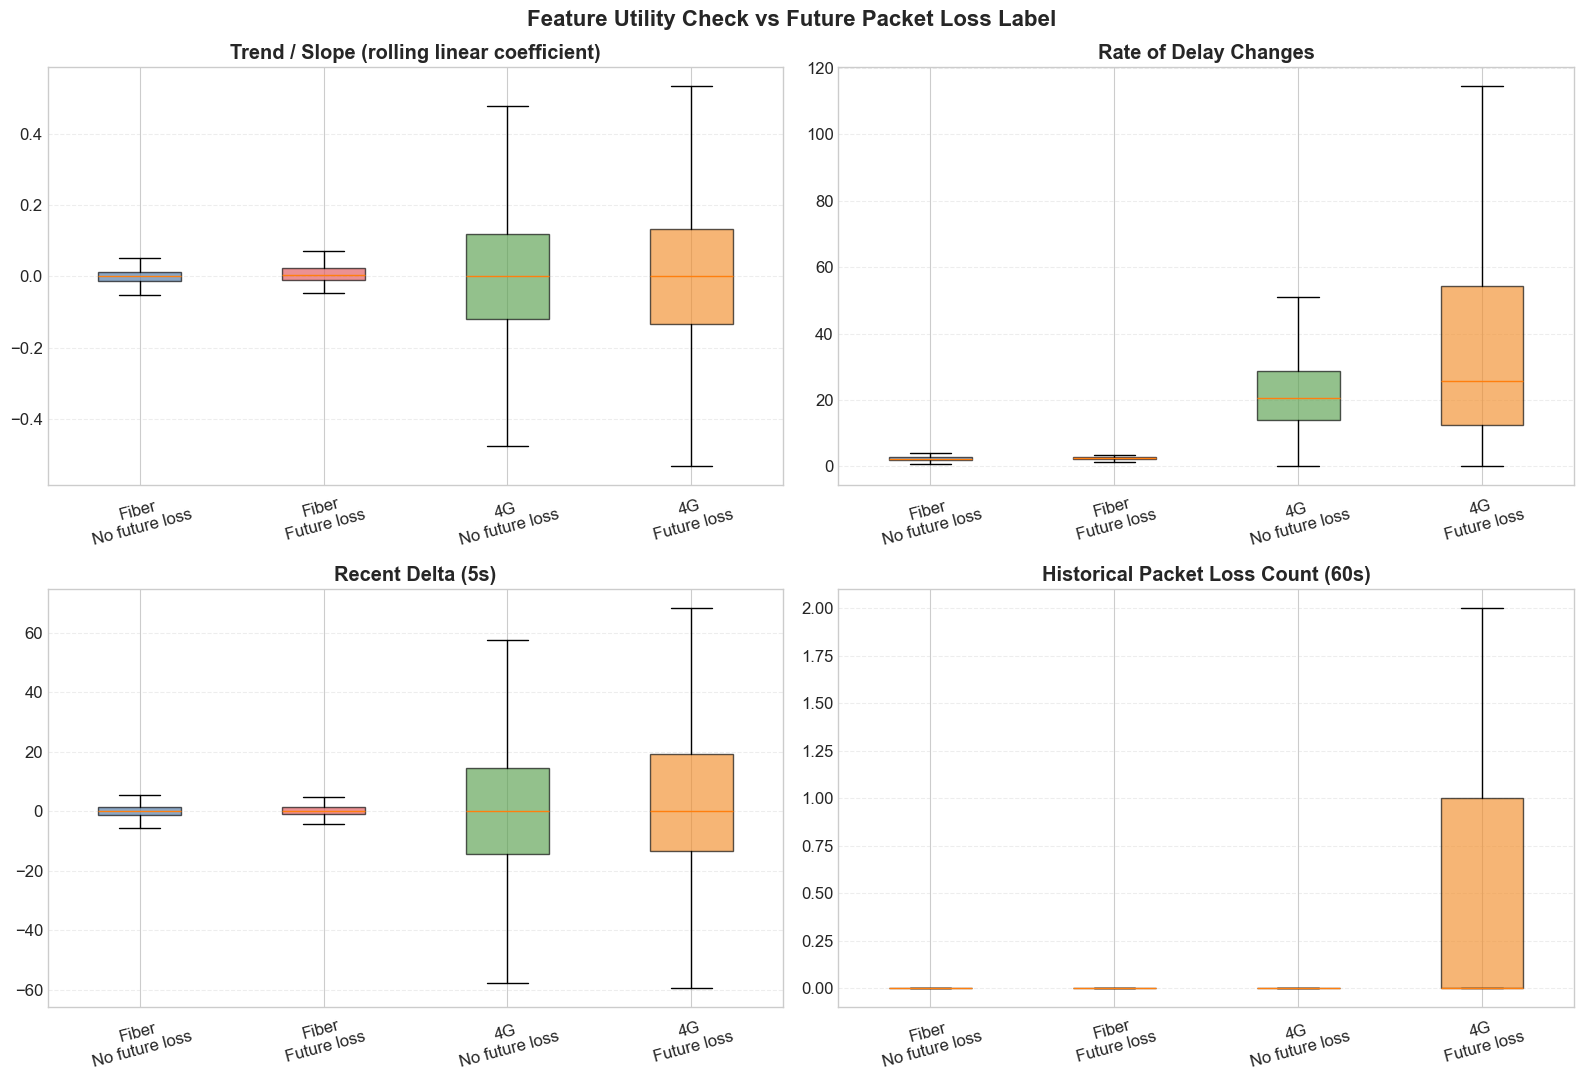

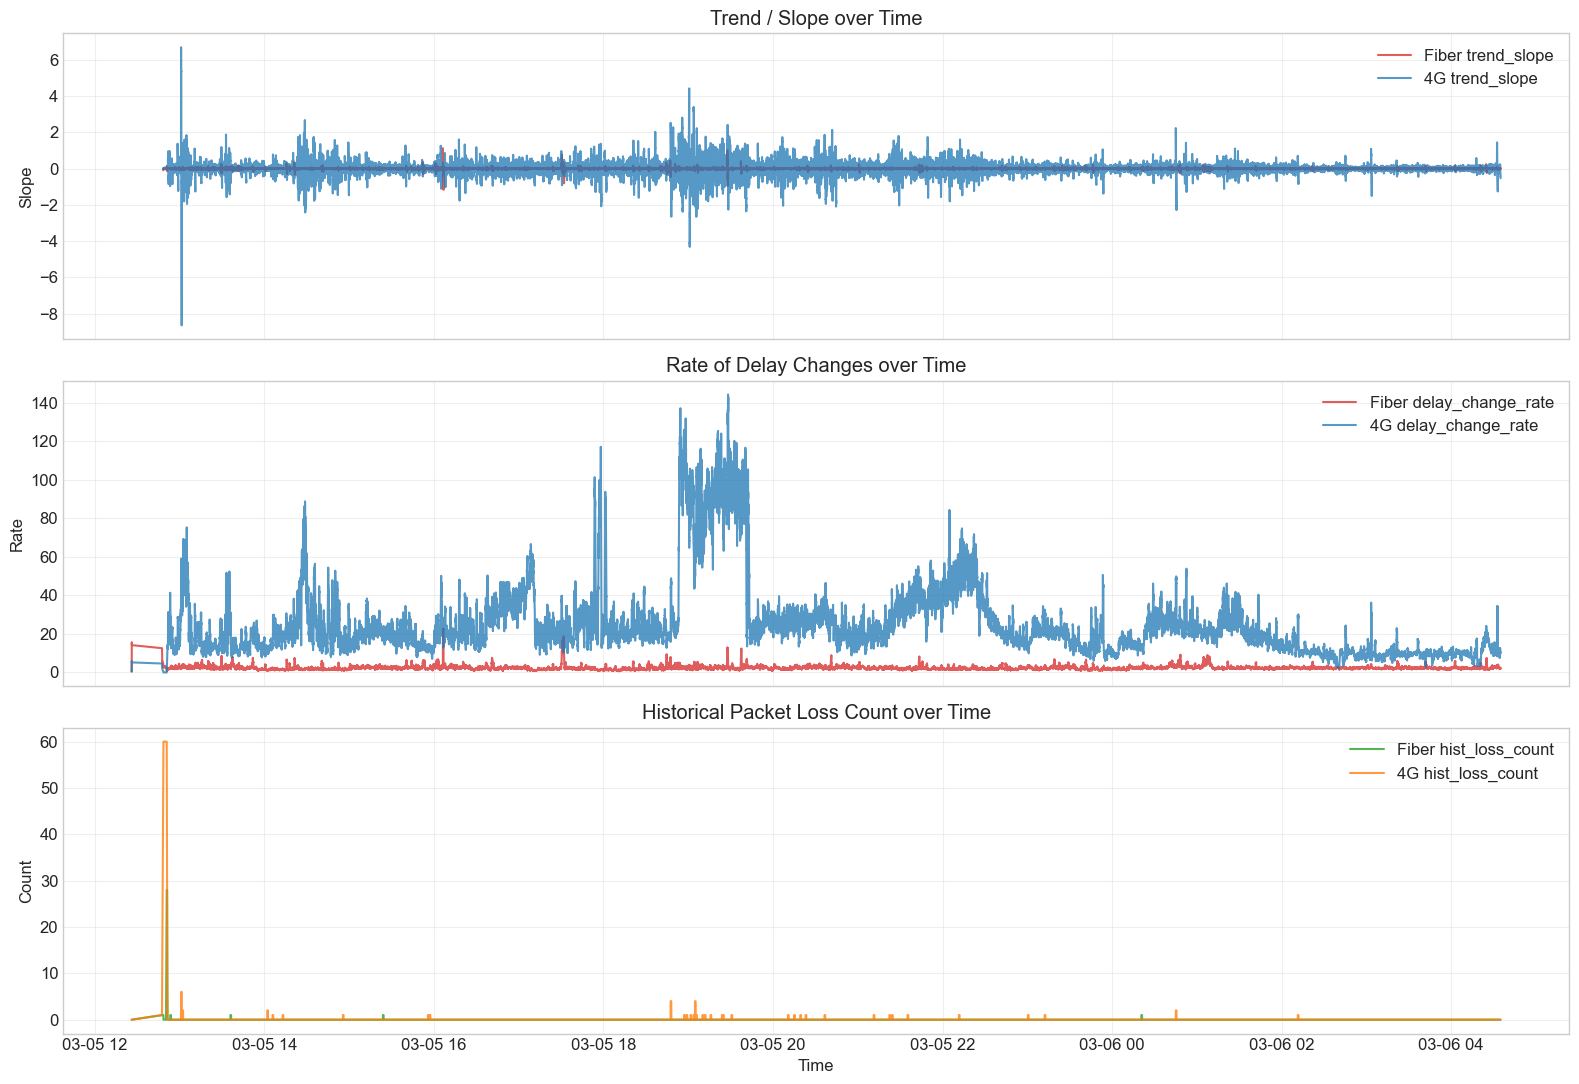

In [82]:
# Visualization: feature distributions conditioned on future packet loss
features_to_plot = [
    ('trend_slope', 'Trend / Slope (rolling linear coefficient)'),
    ('delay_change_rate', 'Rate of Delay Changes'),
    ('recent_delta', f'Recent Delta ({RECENT_DELTA_H}s)'),
    ('hist_loss_count', f'Historical Packet Loss Count ({FEATURE_LOOKBACK}s)')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (feature_col, title) in zip(axes, features_to_plot):
    data_groups = []
    labels = []

    for tech_name, frame in [('Fiber', fiber_features), ('4G', mobile_features)]:
        no_future_loss = frame.loc[frame['future_pkt_loss'] == 0, feature_col].dropna()
        yes_future_loss = frame.loc[frame['future_pkt_loss'] == 1, feature_col].dropna()

        data_groups.extend([no_future_loss, yes_future_loss])
        labels.extend([
            f'{tech_name}\nNo future loss',
            f'{tech_name}\nFuture loss'
        ])

    box = ax.boxplot(data_groups, tick_labels=labels, showfliers=False, patch_artist=True)

    colors = ['#4e79a7', '#e15759', '#59a14f', '#f28e2b']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(title, weight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.tick_params(axis='x', labelrotation=15)

plt.suptitle('Feature Utility Check vs Future Packet Loss Label', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('results/raw_data_visualization/feature_utility_boxplots.png', dpi=300)
plt.show()


# Optional time-series view for intuition on temporal dynamics
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].plot(fiber_features['time'], fiber_features['trend_slope'], label='Fiber trend_slope', color='#d62728', alpha=0.75)
axes[0].plot(mobile_features['time'], mobile_features['trend_slope'], label='4G trend_slope', color='#1f77b4', alpha=0.75)
axes[0].set_ylabel('Slope')
axes[0].set_title('Trend / Slope over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fiber_features['time'], fiber_features['delay_change_rate'], label='Fiber delay_change_rate', color='#d62728', alpha=0.75)
axes[1].plot(mobile_features['time'], mobile_features['delay_change_rate'], label='4G delay_change_rate', color='#1f77b4', alpha=0.75)
axes[1].set_ylabel('Rate')
axes[1].set_title('Rate of Delay Changes over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(fiber_features['time'], fiber_features['hist_loss_count'], label='Fiber hist_loss_count', color='#2ca02c', alpha=0.8)
axes[2].plot(mobile_features['time'], mobile_features['hist_loss_count'], label='4G hist_loss_count', color='#ff7f0e', alpha=0.8)
axes[2].set_ylabel('Count')
axes[2].set_title('Historical Packet Loss Count over Time')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.xlabel('Time')
plt.tight_layout()
plt.savefig('results/raw_data_visualization/feature_utility_timeseries.png', dpi=300)
plt.show()
